# Module 04: Seaborn for Machine Learning
## Notebook 04: Multi-Plot Grids and End-to-End EDA Workflow

Exploratory Data Analysis (EDA) is the disciplined process of performing initial investigations on data to discover patterns, spot anomalies, test hypotheses, and verify assumptions before fitting machine learning models.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Visualize all pairwise feature relationships using **`sns.pairplot()`**.
2. Customize the diagonal, upper, and lower triangles of **`PairGrid`**.
3. Partition multi-factor datasets into small multiples using **`FacetGrid`**.
4. Execute an end-to-end 5-step Exploratory Data Analysis workflow on a classification benchmark.
5. Translate visual EDA insights directly into feature engineering and model selection decisions.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style="ticks")
print("Seaborn loaded!")

Seaborn loaded!


### 1. Pairwise Exploration: `sns.pairplot()`

`pairplot` plots:
- **Off-diagonal panels**: Bivariate scatter plots for every pair of continuous features, colored by class label (`hue`).
- **Diagonal panels**: Univariate density curves (KDE) or histograms showing class separation for that individual feature.

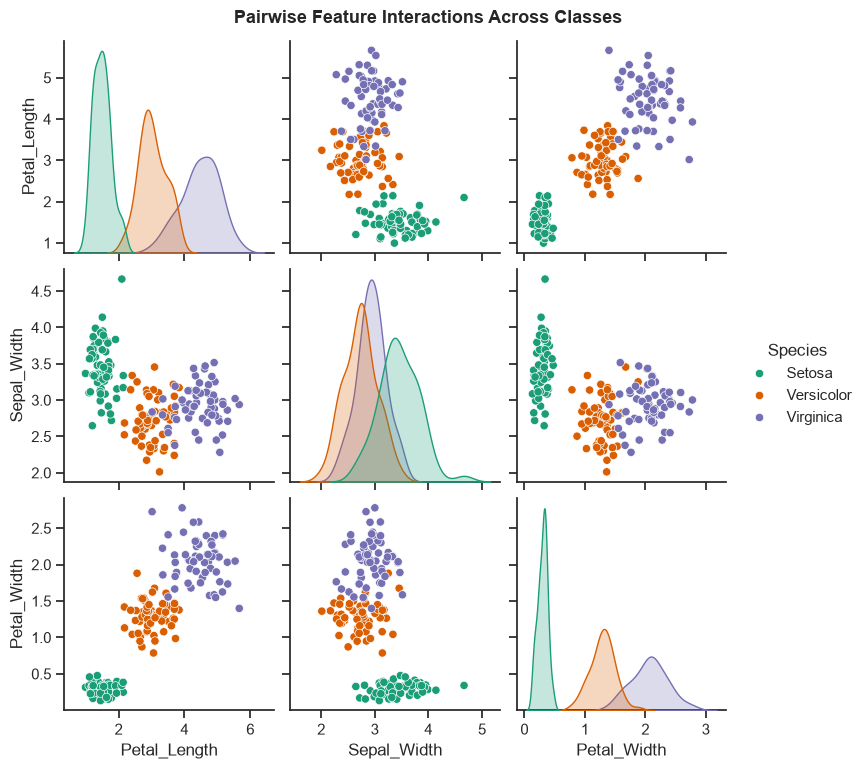

In [2]:
# Generate benchmark 3-class classification dataset (Iris-like)
rng = np.random.default_rng(42)
N_per_class = 60

class_0 = rng.normal(loc=[1.5, 3.5, 0.3], scale=[0.3, 0.4, 0.1], size=(N_per_class, 3))
class_1 = rng.normal(loc=[3.0, 2.7, 1.3], scale=[0.4, 0.3, 0.2], size=(N_per_class, 3))
class_2 = rng.normal(loc=[4.5, 3.0, 2.0], scale=[0.5, 0.3, 0.3], size=(N_per_class, 3))

data_arr = np.vstack([class_0, class_1, class_2])
species = ['Setosa'] * N_per_class + ['Versicolor'] * N_per_class + ['Virginica'] * N_per_class

df_iris = pd.DataFrame(data_arr, columns=['Petal_Length', 'Sepal_Width', 'Petal_Width'])
df_iris['Species'] = species

# Generate Pairplot
pair_fig = sns.pairplot(df_iris, hue='Species', palette='Dark2', corner=False, diag_kind='kde')
pair_fig.fig.suptitle("Pairwise Feature Interactions Across Classes", y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
### 2. Customizing Grids: `sns.PairGrid`

`PairGrid` gives granular control over each region of the matrix:
- `g.map_upper()`: e.g., Scatter plots
- `g.map_lower()`: e.g., Bivariate KDE contours
- `g.map_diag()`: e.g., Histograms

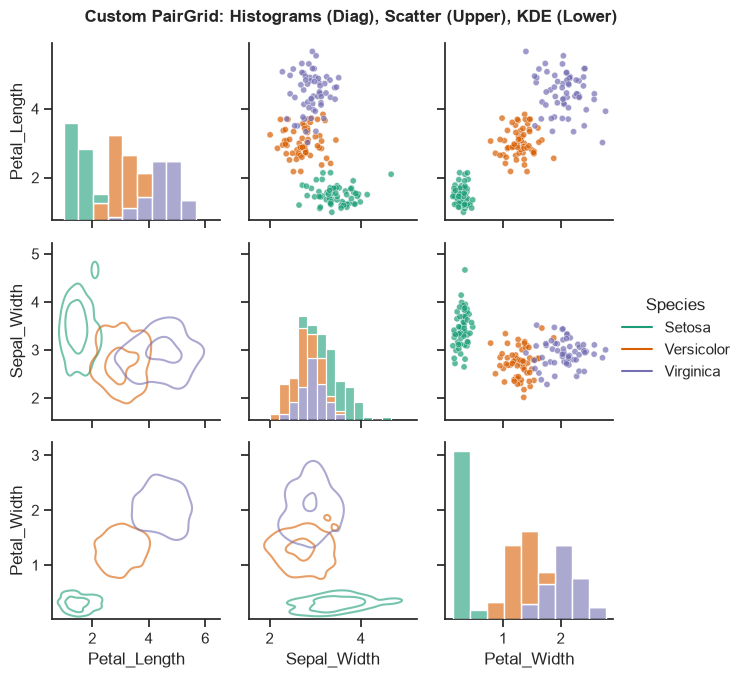

In [3]:
g = sns.PairGrid(df_iris, hue='Species', palette='Dark2', height=2.2)

# Custom mappings per triangle
g.map_diag(sns.histplot, multiple='stack', alpha=0.6)
g.map_upper(sns.scatterplot, s=20, alpha=0.7)
g.map_lower(sns.kdeplot, levels=3, alpha=0.6)

g.add_legend()
g.fig.suptitle("Custom PairGrid: Histograms (Diag), Scatter (Upper), KDE (Lower)", y=1.02, fontsize=12, fontweight='bold')
plt.show()

---
### 3. Small Multiples with `FacetGrid`

`FacetGrid` subsets data based on categorical variables and draws instances of the same plot on separate panels across rows and columns.

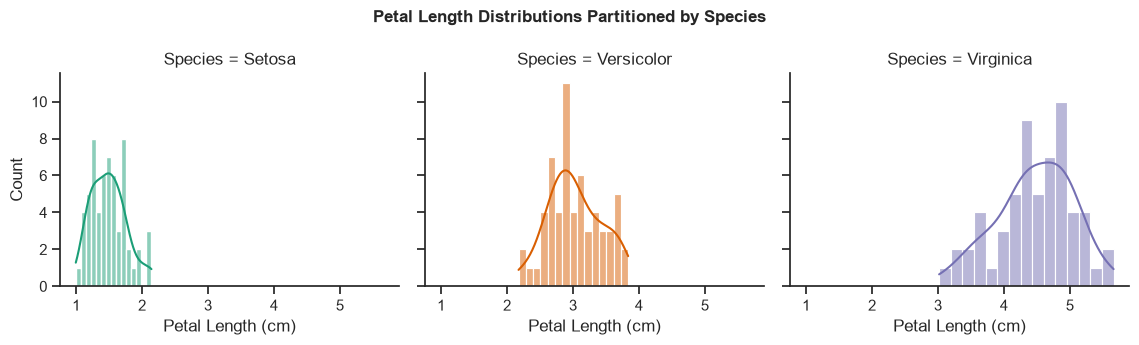

In [4]:
# Conditioning histograms across Species classes
g = sns.FacetGrid(df_iris, col='Species', height=3.5, aspect=1.1, hue='Species', palette='Dark2')
g.map_dataframe(sns.histplot, x='Petal_Length', kde=True, bins=15)
g.set_axis_labels("Petal Length (cm)", "Count")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Petal Length Distributions Partitioned by Species", fontsize=12, fontweight='bold')
plt.show()

---
### 4. End-to-End Exploratory Data Analysis (EDA) Workflow

A professional EDA report follows 5 systematic steps:
1. **Dimension & Data Audit**: Dimensions, missingness, datatypes.
2. **Target Distribution Audit**: Class balance (evaluating whether accuracy is an appropriate metric).
3. **Univariate Feature Analysis**: Detecting feature skewness and heavy tails.
4. **Bivariate Target Separation**: Which individual features clearly separate classes?
5. **Multivariate Interactions**: High correlation and non-linear boundaries.

=== Step 1: Shape & Missingness ===
Dataset Shape: (180, 4)
Missing Values: 0

=== Step 2: Target Balance ===
Species
Setosa        0.333333
Versicolor    0.333333
Virginica     0.333333
Name: proportion, dtype: float64


/tmp/ipykernel_71335/3121452570.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_iris, x='Species', y=feat, palette='Dark2', ax=axes[i])
/tmp/ipykernel_71335/3121452570.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_iris, x='Species', y=feat, palette='Dark2', ax=axes[i])
/tmp/ipykernel_71335/3121452570.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_iris, x='Species', y=feat, palette='Dark2', ax=axes[i])


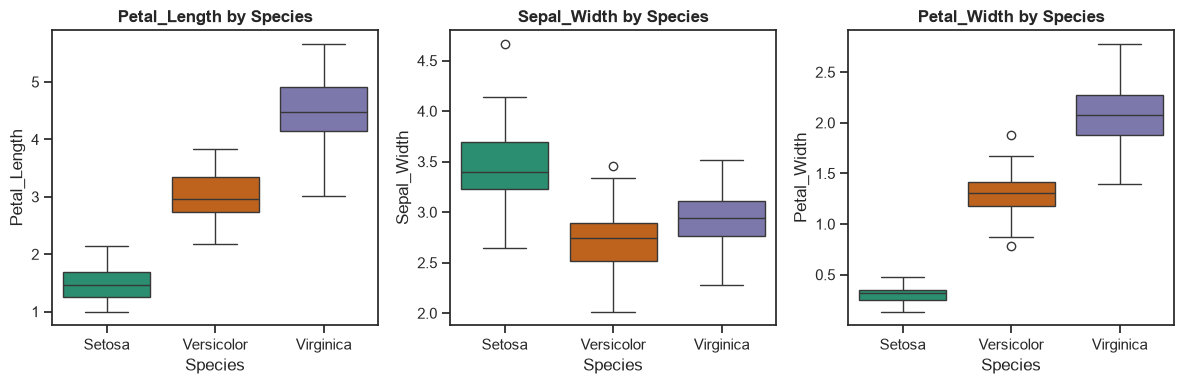

In [5]:
# Step 1: Data Audit
print("=== Step 1: Shape & Missingness ===")
print(f"Dataset Shape: {df_iris.shape}")
print(f"Missing Values: {df_iris.isna().sum().sum()}")

# Step 2: Target Balance
print("\n=== Step 2: Target Balance ===")
print(df_iris['Species'].value_counts(normalize=True))

# Step 4: Individual Feature Separation Boxplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
features = ['Petal_Length', 'Sepal_Width', 'Petal_Width']

for i, feat in enumerate(features):
    sns.boxplot(data=df_iris, x='Species', y=feat, palette='Dark2', ax=axes[i])
    axes[i].set_title(f"{feat} by Species", fontweight='bold')

plt.tight_layout()
plt.show()

### Module 04 Conclusion & Congratulations!
You have successfully completed **Module 04: Seaborn for Machine Learning**!

Throughout these 4 notebooks, you mastered:
1. Figure-level vs Axes-level architecture and continuous density estimation (`01_architecture_and_distribution_plots.ipynb`).
2. Multi-attribute relational plots, bootstrap confidence intervals, and categorical distributions (`02_relational_and_categorical_plots.ipynb`).
3. Masked correlation heatmaps, multicollinearity auditing, and hierarchical clustermaps (`03_matrix_plots_and_correlation_heatmaps.ipynb`).
4. Pair plots, Facet grids, and systematic 5-step EDA reporting (`04_multi_plot_grids_and_eda_workflow.ipynb`).

**Up Next:** Proceed to **Module 05: Scikit-Learn** to build end-to-end supervised and unsupervised machine learning pipelines!